In [104]:
# Packages 
import yfinance as yf
from pprint import pprint 
import pandas as pd 
import seaborn as sns
import plotly.graph_objects as go
import plotly.io as pio
import plotly.express as px
import matplotlib.pyplot as plt 
from datetime import datetime, timedelta, timezone

pio.renderers.default = "browser"   # set once per session
import mplfinance as mpf

In [105]:
# =================================================================================
# 
#              SET SYMBOL, BENCHBARKS, COMPETITORS, and TIMEDELTA
#                                  
# =================================================================================

# SET: SYMBOL, 
#
#   Make sure it match yahoo fiance symbol
#   Most yfinance symbols are SYMBOL-USD
#   eg BTC-USD, ETH-USD
SYMBOL = "LINK-USD"

# SET: BENCHMARKS, list of symbols
BENCHMARKS = [
    "BTC-USD",
    "ETH-USD",
]

# SET: COMPETITORS, list of symbols
COMPETITORS = [
    "PYTH-USD", #Python Network
    "PHA-USD", #PHALA
    "TRB-U", #Tellor Tributres
    "PHB-USD", #Phoenix
    "RED-USD", #RedStone
] 



# SET: TIMEDELTA  -> e.g, TIMEDELTA = 365 
# LEAVE None FOR ALL TIME 
TIMEDELTA = 365

# Automatically set
END_DATE = datetime.now(timezone.utc)
START_DATE = (END_DATE - timedelta(days=365))

if TIMEDELTA:
    print(f"- Symbol: {SYMBOL} \n\n- Start Date: {START_DATE} \n- End Date: {END_DATE}")

else:
    print(f"- Finding Max Data")

assert SYMBOL, "Symbol Must Be Set !!"
assert BENCHMARKS, "Benchmarks Must Be Set !!"
assert COMPETITORS, "Competitors Must Be Set !!"

- Symbol: LINK-USD 

- Start Date: 2025-03-06 02:45:33.719321+00:00 
- End Date: 2026-03-06 02:45:33.719321+00:00


In [106]:
def get_ticker_data(symbol:str) -> pd.DataFrame:
    """ Gets OHLCV Data For Symbol"""
    if not symbol:
        print("Gotta enter a symbol(BTC-USD)")

    try:
        s = yf.Ticker(SYMBOL)
        if TIMEDELTA:
            
            hist = s.history(start=START_DATE, end=END_DATE, interval="1d")


        else:
            hist = s.history(period="max",interval="1d")
        
        df = pd.DataFrame(hist)
        return df.sort_index(ascending=False).drop(["Dividends", "Stock Splits"], axis=1)
    except Exception as e:
        print("Somthing Happened")
        

In [107]:
data = get_ticker_data(SYMBOL)
data 

,Open,High,Low,Close,Volume
Date,,,,,
2026-03-06 00:00:00+00:00,9.198829,9.288336,9.194235,9.262181,770545088
2026-03-04 00:00:00+00:00,8.812367,9.614965,8.700853,9.348465,958769737
2026-03-03 00:00:00+00:00,8.948490,9.002707,8.598036,8.812367,759572365
2026-03-02 00:00:00+00:00,8.672601,9.217735,8.598518,8.948497,852252201
2026-03-01 00:00:00+00:00,8.843731,9.184593,8.554014,8.672350,777710762
...,...,...,...,...,...
2025-03-10 00:00:00+00:00,13.773411,14.512513,12.474602,12.693139,728406483
2025-03-09 00:00:00+00:00,15.251072,15.335954,13.658312,13.773411,472696909
2025-03-08 00:00:00+00:00,15.938867,15.997063,15.156147,15.251074,425972812


In [108]:
def get_master_df() -> pd.DataFrame:
    """ Gets a pd.DataFrame with The Candidate Symbol, Benchmark Symbols and Competitor Symbols"""

    # Running csv
    df = pd.DataFrame()

    SYMBOLS = [SYMBOL] + BENCHMARKS + COMPETITORS
    for symbol in SYMBOLS: 
        c = get_ticker_data(symbol=symbol)
        
        c["Symbol"] = symbol
        
        if symbol == SYMBOL:
            c["Type"] = "Candidate"
        
        else: 
            c["Type"] = "Benchmark" if any(x == symbol for x in BENCHMARKS)  else "Competitor"

        
        c = c.sort_index(ascending=True)
        for col in ["Open", "High", "Low", "Close", "Volume"]:
            standard_name = col + "_normalized"
            c[standard_name] = c[col].astype(float)
            
            first_day = c[standard_name].iloc[0]
            c[standard_name] = (c[standard_name] / first_day) * 100

        df = pd.concat([df, c])

    df = df[["Symbol", "Type", "Open", "High", "Low", "Close", "Volume", "Open_normalized", "High_normalized", "Low_normalized", "Close_normalized", "Volume_normalized"]]
    print("Saving df to ../data/master-data-set.csv")
    df.to_csv("../data/master-data-set.csv")
    return df

In [109]:
df = get_master_df()
df

Saving df to ../data/master-data-set.csv


,Symbol,Type,Open,High,Low,Close,Volume,Open_normalized,High_normalized,Low_normalized,Close_normalized,Volume_normalized
Date,,,,,,,,,,,,
2025-03-06 00:00:00+00:00,LINK-USD,Candidate,16.462299,17.621931,16.413612,17.070051,1078605152,100.000000,100.000000,100.000000,100.000000,100.000000
2025-03-07 00:00:00+00:00,LINK-USD,Candidate,17.070082,17.469847,15.782978,15.938859,1180712381,103.691965,99.136960,96.157858,93.373235,109.466599
2025-03-08 00:00:00+00:00,LINK-USD,Candidate,15.938867,15.997063,15.156147,15.251074,425972812,96.820415,90.779283,92.338887,89.344043,39.492933
2025-03-09 00:00:00+00:00,LINK-USD,Candidate,15.251072,15.335954,13.658312,13.773411,472696909,92.642417,87.027657,83.213320,80.687578,43.824833
2025-03-10 00:00:00+00:00,LINK-USD,Candidate,13.773411,14.512513,12.474602,12.693139,728406483,83.666385,82.354840,76.001562,74.359115,67.532264
...,...,...,...,...,...,...,...,...,...,...,...,...
2026-03-01 00:00:00+00:00,RED-USD,Competitor,8.843731,9.184593,8.554014,8.672350,777710762,53.721116,52.120242,52.115366,50.804475,72.103379
2026-03-02 00:00:00+00:00,RED-USD,Competitor,8.672601,9.217735,8.598518,8.948497,852252201,52.681588,52.308315,52.386508,52.422203,79.014290
2026-03-03 00:00:00+00:00,RED-USD,Competitor,8.948490,9.002707,8.598036,8.812367,759572365,54.357474,51.088082,52.383568,51.624728,70.421726


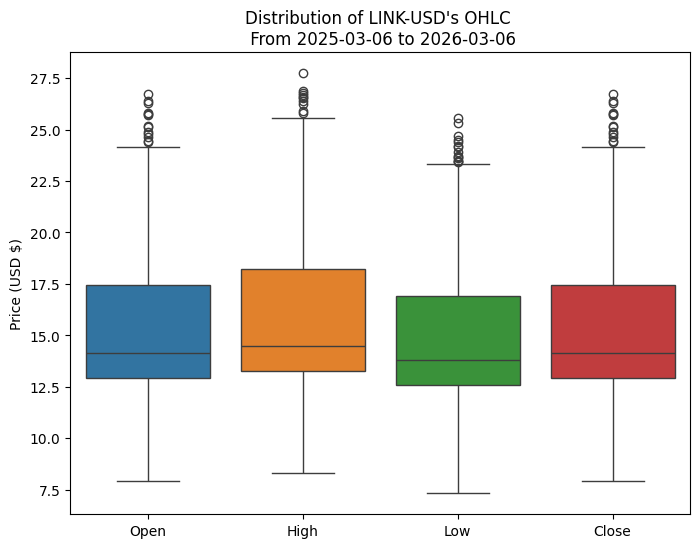

In [110]:
# Create a box plot
c = df[df["Symbol"] == SYMBOL].copy()[["Open", "High", "Low", "Close"]]
plt.figure(figsize=(8, 6))
sns.boxplot(c) #

if TIMEDELTA:
    plt.title(f"Distribution of {SYMBOL}'s OHLC \n From {START_DATE.strftime('%Y-%m-%d')} to {END_DATE.strftime('%Y-%m-%d')}")

else:
    plt.title(f"Distribution of {SYMBOL}'s Historical OHLC's\n")

plt.ylabel("Price (USD $)")
plt.show()

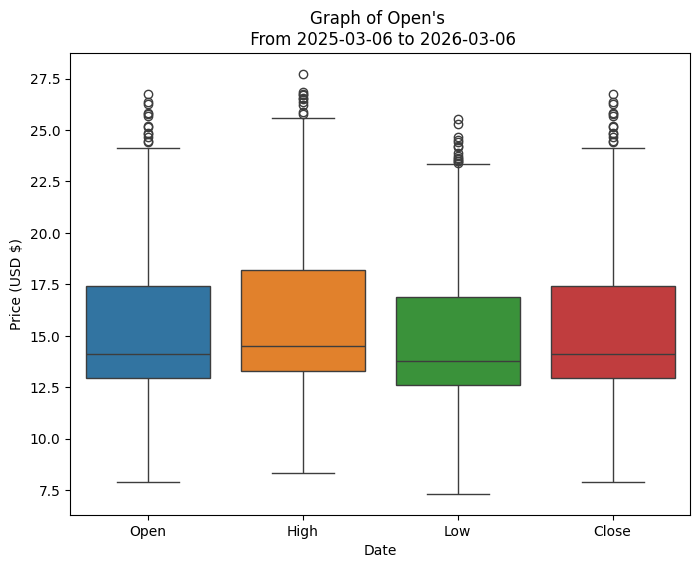

In [111]:
# Create a box plot
c = df[df["Symbol"] == SYMBOL].copy()[["Open", "High", "Low", "Close"]]
plt.figure(figsize=(8, 6))
sns.boxplot(c) #

if TIMEDELTA:
    plt.title(f"Graph of Open's \n From {START_DATE.strftime('%Y-%m-%d')} to {END_DATE.strftime('%Y-%m-%d')}")

else:
    plt.title(f"Graph of Historical Opens's\n")

plt.ylabel("Price (USD $)")
plt.xlabel("Date")
plt.show()

# Interactive Candle Stick Graph For Given Symbol

In [ ]:
df = df[df["Type"] == "Candidate" ].copy()

fig = go.Figure(data=[go.Candlestick(x=df.index,
                open=df['Open'],
                high=df['High'],
                low=df['Low'],
                close=df['Close'])])

fig.update_layout(title='LINK Interactive Chart', yaxis_title='Price')
fig.show()

# Volume (365 Day Window)

In [ ]:
now = datetime.now()
one_year_ago = now - timedelta(days=365)

subset = df.loc['2025-03-05 00:00:00+00:00':'2026-03-05 00:00:00+00:00']
fig = px.bar(subset, x=subset.index, y=subset["Volume"])
fig.show()

# Other Data All time, 52-Week Recent News, and other meta data

In [ ]:
t = yf.Ticker(SYMBOL)
info = t.info          # big dict (varies by ticker)
fast = t.fast_info     # smaller/faster quote-like fields

print('=' * 50 )
pprint(sorted(info.keys())[:40])   # inspect what you actually get
print('=' * 50 )
pprint(type(fast))

['allTimeHigh',
 'allTimeLow',
 'averageDailyVolume10Day',
 'averageDailyVolume3Month',
 'averageVolume',
 'averageVolume10days',
 'circulatingSupply',
 'coinImageUrl',
 'coinMarketCapLink',
 'companyOfficers',
 'corporateActions',
 'cryptoTradeable',
 'currency',
 'customPriceAlertConfidence',
 'dayHigh',
 'dayLow',
 'description',
 'esgPopulated',
 'exchange',
 'exchangeDataDelayedBy',
 'exchangeTimezoneName',
 'exchangeTimezoneShortName',
 'executiveTeam',
 'fiftyDayAverage',
 'fiftyDayAverageChange',
 'fiftyDayAverageChangePercent',
 'fiftyTwoWeekChangePercent',
 'fiftyTwoWeekHigh',
 'fiftyTwoWeekHighChange',
 'fiftyTwoWeekHighChangePercent',
 'fiftyTwoWeekLow',
 'fiftyTwoWeekLowChange',
 'fiftyTwoWeekLowChangePercent',
 'fiftyTwoWeekRange',
 'firstTradeDateMilliseconds',
 'fromCurrency',
 'fullExchangeName',
 'fullyDilutedValue',
 'gmtOffSetMilliseconds',
 'hasPrePostMarketData']
<class 'yfinance.scrapers.quote.FastInfo'>


In [ ]:
news1 = t.get_news(count=20, tab="news")  
news2 = yf.Search(["Chainlink"], news_count=20).news

In [ ]:
print('=' * 50)
print(f'       {len(news1)} Total Articles Found from News1!!')
print('=' * 50 + '\n')

for news in news1:
    url = news.get('content').get('clickThroughUrl').get('url')
    title = news.get('content').get('title')
    pubDate = news.get('content').get('pubDate')
    print(f"Title: {title} \n\t- pubDate: {pubDate} \n\t- url: {url}\n")


       20 Total Articles Found from News1!!

Title: Trump Family-Linked Stablecoin Unveils Live Reserve Tracker After De-Pegging Scare 
	- pubDate: 2026-02-28T11:43:44Z 
	- url: https://finance.yahoo.com/news/trump-family-linked-stablecoin-unveils-114344346.html

Title: Hester Peirce Predicts 'Great Things' After Ex-Chainlink Executive Joins SEC Crypto Task Force As Chief Counsel 
	- pubDate: 2026-02-27T18:31:08Z 
	- url: https://finance.yahoo.com/news/hester-peirce-predicts-great-things-183108450.html

Title: Chainlink Price Surges: What’s Behind Today’s LINK Rally? 
	- pubDate: 2026-02-26T13:36:11Z 
	- url: https://finance.yahoo.com/news/chainlink-price-surges-behind-today-133611685.html

Title: LINK Price Is Finally Up: Chainlink Breaking Out? 
	- pubDate: 2026-02-26T13:27:55Z 
	- url: https://finance.yahoo.com/news/price-finally-chainlink-breaking-132755555.html

Title: Ethereum Pops 11%, but Still Can’t Break Free as Holders Sell at a Loss 
	- pubDate: 2026-02-26T12:00:00Z 
	- url

In [ ]:
print('=' * 50)
print(f'       {len(news2)} Total Articles Found from News2!!')
print('=' * 50 + '\n')
for news in news2:
    title = news.get('title')
    publisher = news.get('publisher')
    link = news.get('link')

    print(f"Title: {title}\n\t- Publisher: {publisher}\n\t Link: {link}\n")


       10 Total Articles Found from News2!!

Title: JPMorgan Identifies 8 CLARITY Act Catalysts—And Altcoins Like XRP Could Benefit
	- Publisher: Benzinga
	 Link: https://finance.yahoo.com/news/jpmorgan-identifies-8-clarity-act-190019335.html

Title: Decentralized AI Company 0G And AIverse Introduce The First Web 4.0 Marketplace – Where AI Agents Own, Trade, and Evolve On-Chain
	- Publisher: GlobeNewswire
	 Link: https://finance.yahoo.com/news/decentralized-ai-company-0g-aiverse-150000758.html

Title: Trump vs. The Banks: Is the Clarity Act a Game Changer?
	- Publisher: 99bitcoins
	 Link: https://finance.yahoo.com/m/b7cee34d-30a9-31ab-a7ff-75f81c54d82b/trump-vs.-the-banks%3A-is-the.html

Title: Crypto Funds Record $1B Weekly Inflows, Ending $4B Outflow Streak
	- Publisher: GuruFocus.com
	 Link: https://finance.yahoo.com/news/crypto-funds-record-1b-weekly-151617661.html

Title: Trade Everything, Always: RWA Perpification as the Missing Layer Between DeFi and Wall Street
	- Publisher: Be

# Live Websocket Data 

In [ ]:
t.live()

Connected to WebSocket.
Subscribed to symbols: ['LINK-USD']
Listening for messages...
{'id': 'LINK-USD', 'price': 9.201551, 'time': '1772697360000', 'currency': 'USD', 'exchange': 'CCC', 'quote_type': 41, 'market_hours': 1, 'change_percent': 3.6169233, 'day_volume': '972747392', 'day_high': 9.371916, 'day_low': 9.201551, 'change': 0.32119656, 'open_price': 9.351733, 'last_size': '972747392', 'price_hint': '2', 'vol_24hr': '972747392', 'vol_all_currencies': '972747392', 'from_currency': 'LINK', 'circulating_supply': 708099970.0, 'market_cap': 6515618300.0}
{'id': 'LINK-USD', 'price': 9.201551, 'time': '1772697360000', 'currency': 'USD', 'exchange': 'CCC', 'quote_type': 41, 'market_hours': 1, 'change_percent': 3.6169233, 'day_volume': '972747392', 'day_high': 9.371916, 'day_low': 9.201551, 'change': 0.32119656, 'open_price': 9.351733, 'last_size': '972747392', 'price_hint': '2', 'vol_24hr': '972747392', 'vol_all_currencies': '972747392', 'from_currency': 'LINK', 'circulating_supply': 708